# Model 1A, CatBoost Experiment 02: Full-History Rotation and W60 Backlog

This experiment applies CatBoost to the feature hypothesis selected by Logistic Regression Experiment 08: the raw Model 1A baseline, full raw-history aircraft rotation, a 24-hour long-turn mask, and compact 60-minute operational backlog. CatBoost handles eligible categorical fields natively and can learn nonlinear interactions between aircraft availability, airport pressure, airline, route, schedule, and weather.

Hyperparameters and tree count are selected only from five expanding 2019 folds. The operating threshold is selected only from held-out 2019 probabilities. The selected model is refitted on all 2019 rows and evaluated once on 2023. The 2024 dataset is not loaded. Final BTS tail assignment still makes rotation-based performance a retrospective upper bound.

In [1]:
AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "DepDel15"

BACKLOG_WINDOW_MINUTES = 60
LONG_TURN_HOURS = 24
RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 4
MAX_ITERATIONS = 1000
EARLY_STOPPING_ROUNDS = 75

In [2]:
from itertools import product
from pathlib import Path
from time import perf_counter

import catboost
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score,
    balanced_accuracy_score, brier_score_loss, f1_score,
    matthews_corrcoef, precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"CatBoost version: {catboost.__version__}")

CatBoost version: 1.2.10


## Pair and validate the Experiment 08 feature paths

Full-history rotation and W60 backlog files are loaded separately and paired only after strict row-identity checks. The notebook does not write a combined feature dataset.

In [3]:
def find_project_root(start: Path) -> Path:
    required = [
        Path("data/features") / f"{AIRPORT}_{year}_departures_{kind}.csv"
        for year in (TRAIN_YEAR, VALIDATION_YEAR)
        for kind in ("rotation_full_history", f"backlog_w{BACKLOG_WINDOW_MINUTES}")
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required experiment files: {required}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
rotation_frames, backlog_frames = {}, {}
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    rotation_path = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{year}_departures_rotation_full_history.csv"
    backlog_path = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{year}_departures_backlog_w{BACKLOG_WINDOW_MINUTES}.csv"
    rotation_frames[partition] = pd.read_csv(rotation_path, low_memory=False)
    backlog_frames[partition] = pd.read_csv(backlog_path, low_memory=False)
    print(f"{partition:10s}: {len(rotation_frames[partition]):,} rotation rows <- {rotation_path.name}")
    print(f"{'':10s}  {len(backlog_frames[partition]):,} backlog rows  <- {backlog_path.name}")

training  : 107,430 rotation rows <- JFK_2019_departures_rotation_full_history.csv
            107,430 backlog rows  <- JFK_2019_departures_backlog_w60.csv


validation: 109,983 rotation rows <- JFK_2023_departures_rotation_full_history.csv
            109,983 backlog rows  <- JFK_2023_departures_backlog_w60.csv


In [4]:
ROTATION_FEATURES = [
    "ROTATION_STATUS", "ROTATION_MATCH_FOUND", "ROTATION_INBOUND_ORIGIN",
    "ROTATION_SCHEDULED_TURN_MINUTES",
    "ROTATION_INBOUND_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_OVERDUE_MINUTES",
    "ROTATION_LOG_INBOUND_OVERDUE_MINUTES",
    "ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_LOG_ACTUAL_TURN_MINUTES",
    "ROTATION_INBOUND_ARR_DELAY", "ROTATION_INBOUND_DELAYED_15",
    "ROTATION_LOG_SCHEDULED_TURN_MINUTES",
]
ROTATION_AUDIT_COLUMNS = [
    "ROTATION_TARGET_CUTOFF_UTC", "ROTATION_PRIOR_REPORTING_AIRLINE",
    "ROTATION_PRIOR_FLIGHT_NUMBER", "ROTATION_PRIOR_FLIGHT_DATE",
    "ROTATION_PRIOR_SCHEDULED_DEPARTURE_UTC",
    "ROTATION_PRIOR_SCHEDULED_ARRIVAL_UTC",
    "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC",
    "ROTATION_SCHEDULE_RECONSTRUCTION_ERROR_MINUTES",
]
BACKLOG_PREFIX = f"BACKLOG_W{BACKLOG_WINDOW_MINUTES}"
FULL_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_SCHEDULED_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_DELAYED_DEPARTURE_COUNT",
    f"{BACKLOG_PREFIX}_DELAY_RATE", f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY_MINUTES",
    f"{BACKLOG_PREFIX}_TOTAL_DEP_DELAY_MINUTES",
]
COMPACT_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
]
IDENTITY_COLUMNS = [
    "FlightDate", "Reporting_Airline", "Flight_Number_Reporting_Airline",
    "Origin", "Dest", "CRSDepTime", "Tail_Number", TARGET,
]

combined_frames, source_rows = {}, []
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    rotation, backlog = rotation_frames[partition], backlog_frames[partition]
    required_rotation = {"FlightDate", "DATE", "Origin", TARGET, *ROTATION_FEATURES, *ROTATION_AUDIT_COLUMNS}
    required_backlog = {"FlightDate", "DATE", "Origin", TARGET, *FULL_BACKLOG_FEATURES}
    assert not required_rotation.difference(rotation.columns)
    assert not required_backlog.difference(backlog.columns)
    assert len(rotation) == len(backlog)
    pd.testing.assert_frame_equal(rotation[IDENTITY_COLUMNS], backlog[IDENTITY_COLUMNS], check_dtype=False)
    rotation["FlightDate"] = pd.to_datetime(rotation["FlightDate"], errors="raise")
    backlog["FlightDate"] = pd.to_datetime(backlog["FlightDate"], errors="raise")
    cutoff = pd.to_datetime(backlog["DATE"], errors="raise")
    assert rotation["FlightDate"].dt.year.eq(year).all() and rotation["Origin"].eq(AIRPORT).all()
    match = pd.to_numeric(rotation["ROTATION_MATCH_FOUND"], errors="raise")
    arrived = pd.to_numeric(rotation["ROTATION_INBOUND_ARRIVED_BY_CUTOFF"], errors="raise")
    not_arrived = pd.to_numeric(rotation["ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF"], errors="raise")
    assert match.eq(arrived + not_arrived).all()
    actual_only = ["ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_INBOUND_ARR_DELAY",
                   "ROTATION_INBOUND_DELAYED_15", "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC"]
    assert not rotation.loc[arrived.eq(0), actual_only].notna().any().any()
    scheduled, completed, pending, delayed_count = (
        pd.to_numeric(backlog[column], errors="raise") for column in FULL_BACKLOG_FEATURES[:4]
    )
    assert scheduled.eq(completed + pending).all() and delayed_count.le(completed).all()
    same_cutoff_variants = (backlog.assign(_CUTOFF=cutoff)
        .groupby("_CUTOFF", sort=False)[FULL_BACKLOG_FEATURES]
        .nunique(dropna=False).to_numpy().max(initial=0))
    assert same_cutoff_variants <= 1
    combined = rotation.copy()
    for column in COMPACT_BACKLOG_FEATURES:
        combined[column] = backlog[column].to_numpy()
    combined_frames[partition] = combined
    source_rows.append({
        "partition": partition, "year": year, "rows": len(combined),
        "delay_rate": combined[TARGET].mean(), "rotation_match_rate": match.mean(),
        "not_arrived_rows": int(not_arrived.sum()), "mean_pending": pending.mean(),
        "same_cutoff_backlog_violations": int(same_cutoff_variants > 1),
    })
source_summary = pd.DataFrame(source_rows).set_index("partition")
source_summary

,year,rows,delay_rate,rotation_match_rate,not_arrived_rows,mean_pending,same_cutoff_backlog_violations
partition,,,,,,,
training,2019,107430,0.1877,0.9665,3133,2.4552,0
validation,2023,109983,0.2364,0.9554,3565,3.0245,0


## Apply the 24-hour mask and define the native CatBoost manifest

The feature set exactly matches Experiment 08 at the source-field level. CatBoost receives six native categorical fields and 30 numeric fields. Long rotation matches are replaced by `LONG_TURN_EXCLUDED`; their other rotation values remain missing. Numeric missing values remain `NaN` for CatBoost, while missing categories receive the explicit label `MISSING`.

In [5]:
def mask_long_turns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    long_turn = pd.to_numeric(result["ROTATION_SCHEDULED_TURN_MINUTES"], errors="coerce").gt(LONG_TURN_HOURS * 60)
    result.loc[long_turn, ROTATION_FEATURES] = np.nan
    result.loc[long_turn, "ROTATION_STATUS"] = "LONG_TURN_EXCLUDED"
    return result


model_frames = {partition: mask_long_turns(frame) for partition, frame in combined_frames.items()}
BASE_CATEGORICAL_FEATURES = ["Month", "DayOfWeek", "Reporting_Airline", "Dest"]
BASE_NUMERIC_FEATURES = [
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES", "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES", "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES", "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "HourlyDewPointTemperature", "HourlyDryBulbTemperature",
    "HourlyPrecipitation", "HourlyRelativeHumidity",
    "HourlyVisibility", "HourlyWindSpeed",
]
ROTATION_CATEGORICAL = ["ROTATION_STATUS", "ROTATION_INBOUND_ORIGIN"]
ROTATION_NUMERIC = [column for column in ROTATION_FEATURES if column not in ROTATION_CATEGORICAL]
categorical_features = [*BASE_CATEGORICAL_FEATURES, *ROTATION_CATEGORICAL]
numeric_features = [*BASE_NUMERIC_FEATURES, *ROTATION_NUMERIC, *COMPACT_BACKLOG_FEATURES]
feature_columns = [*categorical_features, *numeric_features]
required_columns = list(dict.fromkeys(["FlightDate", "CRSDepTime", TARGET, *feature_columns]))
assert len(categorical_features) == 6 and len(numeric_features) == 30
assert len(feature_columns) == len(set(feature_columns)) == 36
for partition, frame in model_frames.items():
    assert not set(required_columns).difference(frame.columns), partition
forbidden = {
    TARGET, "DepTime", "DepDelay", "DepDelayMinutes", "TaxiOut",
    "WheelsOff", "WheelsOn", "TaxiIn", "ArrTime", "ArrDelay",
    "ArrDelayMinutes", "ArrDel15", "ActualElapsedTime", "AirTime",
    "Tail_Number", *ROTATION_AUDIT_COLUMNS,
}
assert not forbidden.intersection(feature_columns)
print(pd.Series({
    "source fields": len(feature_columns), "native categorical": len(categorical_features),
    "numeric": len(numeric_features), "rotation fields": len(ROTATION_FEATURES),
    "W60 backlog fields": len(COMPACT_BACKLOG_FEATURES),
}))

source fields         36
native categorical     6
numeric               30
rotation fields       13
W60 backlog fields     3
dtype: int64


In [6]:
def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)
    for column in categorical_features:
        frame[column] = frame[column].astype("string").fillna("MISSING").astype(str)
    for column in numeric_features:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


train_model_df = prepare_model_frame(model_frames["training"])
validation_model_df = prepare_model_frame(model_frames["validation"])
X_train = train_model_df[feature_columns].reset_index(drop=True)
y_train = train_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
X_validation = validation_model_df[feature_columns].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)
assert training_dates.max() < validation_dates.min()
missing_summary = pd.DataFrame({
    "training_missing": X_train.isna().sum(),
    "validation_missing": X_validation.isna().sum(),
})
missing_summary[missing_summary.sum(axis=1).gt(0)]

,training_missing,validation_missing
ASPM_NEXT_SCHEDULED_DEPARTURES,1,0
ASPM_NEXT_SCHEDULED_ARRIVALS,1,0
HourlyDewPointTemperature,46,0
HourlyPrecipitation,22,21
HourlyVisibility,0,28
ROTATION_MATCH_FOUND,8281,8409
ROTATION_SCHEDULED_TURN_MINUTES,11877,13310
ROTATION_INBOUND_ARRIVED_BY_CUTOFF,8281,8409
ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF,8281,8409
ROTATION_INBOUND_OVERDUE_MINUTES,11877,13310


In [7]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    day_blocks = np.array_split(np.array(sorted(pd.unique(normalized))), n_splits + 1)
    splits, rows = [], []
    for fold in range(1, n_splits + 1):
        train_days, heldout_days = np.concatenate(day_blocks[:fold]), day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold, "train_rows": len(train_idx), "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })
    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(training_dates, y_train, N_TIME_SPLITS)
fold_summary

,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17737,18776,2019-03-02,2019-03-03,2019-05-02,0.1892,0.1674
2,36513,18150,2019-05-02,2019-05-03,2019-07-02,0.1780,0.2072
3,54663,17758,2019-07-02,2019-07-03,2019-09-01,0.1877,0.2577
4,72421,17686,2019-09-01,2019-09-02,2019-11-01,0.2048,0.1384
5,90107,17323,2019-11-01,2019-11-02,2019-12-31,0.1918,0.1666


## Training-only temporal search with fold-local early stopping

Sixteen compact candidates compare depths 4 and 6, learning rates 0.03 and 0.10, L2 leaf regularization 3 and 10, and no class weighting versus automatic balanced weighting. Each fold stops after 75 iterations without improvement in validation PRAUC. Mean average precision calculated from held-out probabilities selects the configuration; the median fold-best tree count determines the final model size.

In [8]:
parameter_candidates = [
    {"depth": depth, "learning_rate": rate, "l2_leaf_reg": regularization,
     "class_weighting": class_weighting}
    for depth, rate, regularization, class_weighting
    in product([4, 6], [0.03, 0.10], [3, 10], ["None", "Balanced"])
]

def make_catboost_model(parameters, iterations=MAX_ITERATIONS, use_best_model=True):
    return CatBoostClassifier(
        iterations=iterations, loss_function="Logloss", eval_metric="PRAUC:type=Classic",
        depth=parameters["depth"], learning_rate=parameters["learning_rate"],
        l2_leaf_reg=parameters["l2_leaf_reg"],
        auto_class_weights=None if parameters["class_weighting"] == "None" else parameters["class_weighting"],
        random_seed=RANDOM_STATE, thread_count=N_JOBS, allow_writing_files=False,
        verbose=False, use_best_model=use_best_model,
    )


search_start = perf_counter()
search_rows = []
for candidate_number, parameters in enumerate(parameter_candidates, start=1):
    for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
        model = make_catboost_model(parameters)
        model.fit(
            X_train.iloc[train_idx], y_train.iloc[train_idx],
            cat_features=categorical_features,
            eval_set=(X_train.iloc[heldout_idx], y_train.iloc[heldout_idx]),
            early_stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False,
        )
        probabilities = model.predict_proba(X_train.iloc[heldout_idx])[:, 1]
        search_rows.append({
            "candidate": candidate_number, "fold": fold_number, **parameters,
            "best_iteration": model.get_best_iteration() + 1,
            "average_precision": average_precision_score(y_train.iloc[heldout_idx], probabilities),
            "roc_auc": roc_auc_score(y_train.iloc[heldout_idx], probabilities),
            "brier_score": brier_score_loss(y_train.iloc[heldout_idx], probabilities),
        })
    print(f"Completed candidate {candidate_number}/{len(parameter_candidates)}: {parameters}")

search_seconds = perf_counter() - search_start
fold_search_results = pd.DataFrame(search_rows)
candidate_results = (fold_search_results
    .groupby(["candidate", "depth", "learning_rate", "l2_leaf_reg", "class_weighting"], as_index=False)
    .agg(mean_average_precision=("average_precision", "mean"),
         std_average_precision=("average_precision", "std"),
         mean_roc_auc=("roc_auc", "mean"), mean_brier_score=("brier_score", "mean"),
         median_best_iteration=("best_iteration", "median"),
         min_best_iteration=("best_iteration", "min"),
         max_best_iteration=("best_iteration", "max"))
    .sort_values(["mean_average_precision", "mean_roc_auc"], ascending=False))
best_candidate = candidate_results.iloc[0]
selected_parameters = {
    "depth": int(best_candidate["depth"]),
    "learning_rate": float(best_candidate["learning_rate"]),
    "l2_leaf_reg": float(best_candidate["l2_leaf_reg"]),
    "class_weighting": str(best_candidate["class_weighting"]),
}
selected_iterations = max(1, int(best_candidate["median_best_iteration"]))
print(f"Temporal search completed in {search_seconds:,.1f} seconds")
print(f"Best mean temporal-validation AP: {best_candidate['mean_average_precision']:.4f}")
print(f"Selected parameters: {selected_parameters}")
print(f"Selected iteration count: {selected_iterations}")
candidate_results

Completed candidate 1/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'class_weighting': 'None'}


Completed candidate 2/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'class_weighting': 'Balanced'}


Completed candidate 3/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 10, 'class_weighting': 'None'}


Completed candidate 4/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 10, 'class_weighting': 'Balanced'}


Completed candidate 5/16: {'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'class_weighting': 'None'}


...

Completed candidate 13/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'class_weighting': 'None'}


Completed candidate 14/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'class_weighting': 'Balanced'}


Completed candidate 15/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 10, 'class_weighting': 'None'}


Completed candidate 16/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 10, 'class_weighting': 'Balanced'}
Temporal search completed in 871.7 seconds
Best mean temporal-validation AP: 0.7025
Selected parameters: {'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'class_weighting': 'None'}
Selected iteration count: 683


,candidate,depth,learning_rate,l2_leaf_reg,class_weighting,mean_average_precision,std_average_precision,mean_roc_auc,mean_brier_score,median_best_iteration,min_best_iteration,max_best_iteration
8,9,6,0.0300,3,None,0.7025,0.0602,0.8451,0.0915,683.0000,328,988
10,11,6,0.0300,10,None,0.7024,0.0609,0.8446,0.0915,504.0000,448,683
0,1,4,0.0300,3,None,0.7007,0.0598,0.8441,0.0919,883.0000,385,1000
14,15,6,0.1000,10,None,0.7007,0.0600,0.8433,0.0919,206.0000,124,291
2,3,4,0.0300,10,None,0.7005,0.0608,0.8439,0.0920,861.0000,431,986
6,7,4,0.1000,10,None,0.7003,0.0599,0.8441,0.0922,315.0000,102,357
12,13,6,0.1000,3,None,0.6996,0.0611,0.8422,0.0922,166.0000,68,222
4,5,4,0.1000,3,None,0.6991,0.0604,0.8427,0.0923,248.0000,89,618
11,12,6,0.0300,10,Balanced,0.6966,0.0614,0.8431,0.1338,623.0000,251,694
3,4,4,0.0300,10,Balanced,0.6966,0.0606,0.8432,0.1358,951.0000,634,996


## Select the operating threshold using 2019 only

The selected parameters and fixed median tree count are refitted on each expanding training fold. Thresholds from 0.05 through 0.50 are ranked by F1 on held-out 2019 probabilities, with balanced accuracy and precision as tie-breakers.

In [9]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold, "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


oof_probabilities = np.full(len(y_train), np.nan)
for train_idx, heldout_idx in temporal_splits:
    fold_model = make_catboost_model(selected_parameters, iterations=selected_iterations, use_best_model=False)
    fold_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx],
                   cat_features=categorical_features, verbose=False)
    oof_probabilities[heldout_idx] = fold_model.predict_proba(X_train.iloc[heldout_idx])[:, 1]
oof_mask = np.isfinite(oof_probabilities)
oof_y, oof_p = y_train.to_numpy()[oof_mask], oof_probabilities[oof_mask]
threshold_rows = []
for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2):
    row = evaluate_probabilities(oof_y, oof_p, threshold)
    threshold_rows.append(row)
threshold_results = pd.DataFrame(threshold_rows)
selected_threshold = float(threshold_results.sort_values(
    ["f1", "balanced_accuracy", "precision"], ascending=False
).iloc[0]["threshold"])
print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only selected threshold: {selected_threshold:.2f}")
threshold_results.sort_values(["f1", "balanced_accuracy", "precision"], ascending=False).head(10)

Threshold-selection rows: 89,693
Training-only selected threshold: 0.32


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
27,0.3200,0.8741,0.7572,0.7021,0.5702,0.6294,0.5589,0.8485,0.7134,0.0918
26,0.3100,0.8722,0.7589,0.6902,0.5777,0.6290,0.5557,0.8485,0.7134,0.0918
25,0.3000,0.8700,0.7608,0.6770,0.5862,0.6283,0.5522,0.8485,0.7134,0.0918
28,0.3300,0.8752,0.7549,0.7115,0.5623,0.6282,0.5600,0.8485,0.7134,0.0918
29,0.3400,0.8766,0.7532,0.7221,0.5557,0.6281,0.5625,0.8485,0.7134,0.0918
24,0.2900,0.8676,0.7628,0.6639,0.5951,0.6276,0.5486,0.8485,0.7134,0.0918
23,0.2800,0.8653,0.7648,0.6516,0.6040,0.6269,0.5454,0.8485,0.7134,0.0918
30,0.3500,0.8776,0.7510,0.7316,0.5483,0.6268,0.5637,0.8485,0.7134,0.0918
31,0.3600,0.8787,0.7489,0.7414,0.5415,0.6259,0.5653,0.8485,0.7134,0.0918
22,0.2700,0.8621,0.7659,0.6377,0.6121,0.6246,0.5404,0.8485,0.7134,0.0918


## Refit on all 2019 rows and evaluate 2023

No 2023 outcome influences model fitting, tree count, hyperparameters, or threshold selection. Logistic Regression 08 is included as a documented benchmark rather than refitted.

In [10]:
final_fit_start = perf_counter()
best_catboost_model = make_catboost_model(
    selected_parameters, iterations=selected_iterations, use_best_model=False
)
best_catboost_model.fit(X_train, y_train, cat_features=categorical_features, verbose=False)
final_fit_seconds = perf_counter() - final_fit_start
validation_probabilities = best_catboost_model.predict_proba(X_validation)[:, 1]
evaluation_results = pd.DataFrame([
    {"model": "Logistic Regression 08 (documented)", "threshold": 0.50,
     "accuracy": 0.8430, "balanced_accuracy": 0.6953, "precision": 0.8395,
     "recall": 0.4151, "f1": 0.5555, "mcc": 0.5164,
     "roc_auc": 0.8267, "average_precision": 0.7053, "brier_score": 0.1192},
    {"model": "CatBoost 02 (default)", **evaluate_probabilities(y_validation, validation_probabilities, 0.50)},
    {"model": "CatBoost 02 (training-selected)",
     **evaluate_probabilities(y_validation, validation_probabilities, selected_threshold)},
]).set_index("model")
print(f"Final all-2019 fit: {final_fit_seconds:,.1f} seconds; trees: {best_catboost_model.tree_count_:,}")
evaluation_results

Final all-2019 fit: 26.6 seconds; trees: 683


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
Logistic Regression 08 (documented),0.5000,0.8430,0.6953,0.8395,0.4151,0.5555,0.5164,0.8267,0.7053,0.1192
CatBoost 02 (default),0.5000,0.8548,0.7139,0.8796,0.4467,0.5925,0.5592,0.8511,0.7473,0.1100
CatBoost 02 (training-selected),0.3200,0.8510,0.7516,0.7443,0.5631,0.6411,0.5579,0.8511,0.7473,0.1100


In [11]:
validation_frame = model_frames["validation"].sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
status = validation_frame["ROTATION_STATUS"].astype("string")
populations = {
    "all rows": np.ones(len(validation_frame), dtype=bool),
    "excluding NOT_ARRIVED": status.ne("NOT_ARRIVED").to_numpy(),
    "ARRIVED": status.eq("ARRIVED").to_numpy(),
    "rotation unavailable/excluded": status.isin([
        "NO_PRIOR_EVENT", "PREVIOUS_EVENT_DEPARTURE", "MISSING_TAIL", "LONG_TURN_EXCLUDED"
    ]).to_numpy(),
}
diagnostic_rows = []
for population, mask in populations.items():
    subgroup_y, subgroup_p = y_validation.to_numpy()[mask], validation_probabilities[mask]
    diagnostic_rows.append({
        "population": population, "rows": int(mask.sum()),
        "prevalence": subgroup_y.mean(),
        "average_precision": average_precision_score(subgroup_y, subgroup_p),
        "roc_auc": roc_auc_score(subgroup_y, subgroup_p),
        "brier_score": brier_score_loss(subgroup_y, subgroup_p),
    })
diagnostic_results = pd.DataFrame(diagnostic_rows).set_index("population")
diagnostic_results

,rows,prevalence,average_precision,roc_auc,brier_score
population,,,,,
all rows,109983,0.2364,0.7473,0.8511,0.1100
excluding NOT_ARRIVED,106418,0.2109,0.6732,0.8276,0.1136
ARRIVED,93108,0.1858,0.6568,0.8214,0.1025
rotation unavailable/excluded,13310,0.3866,0.6884,0.7628,0.1912


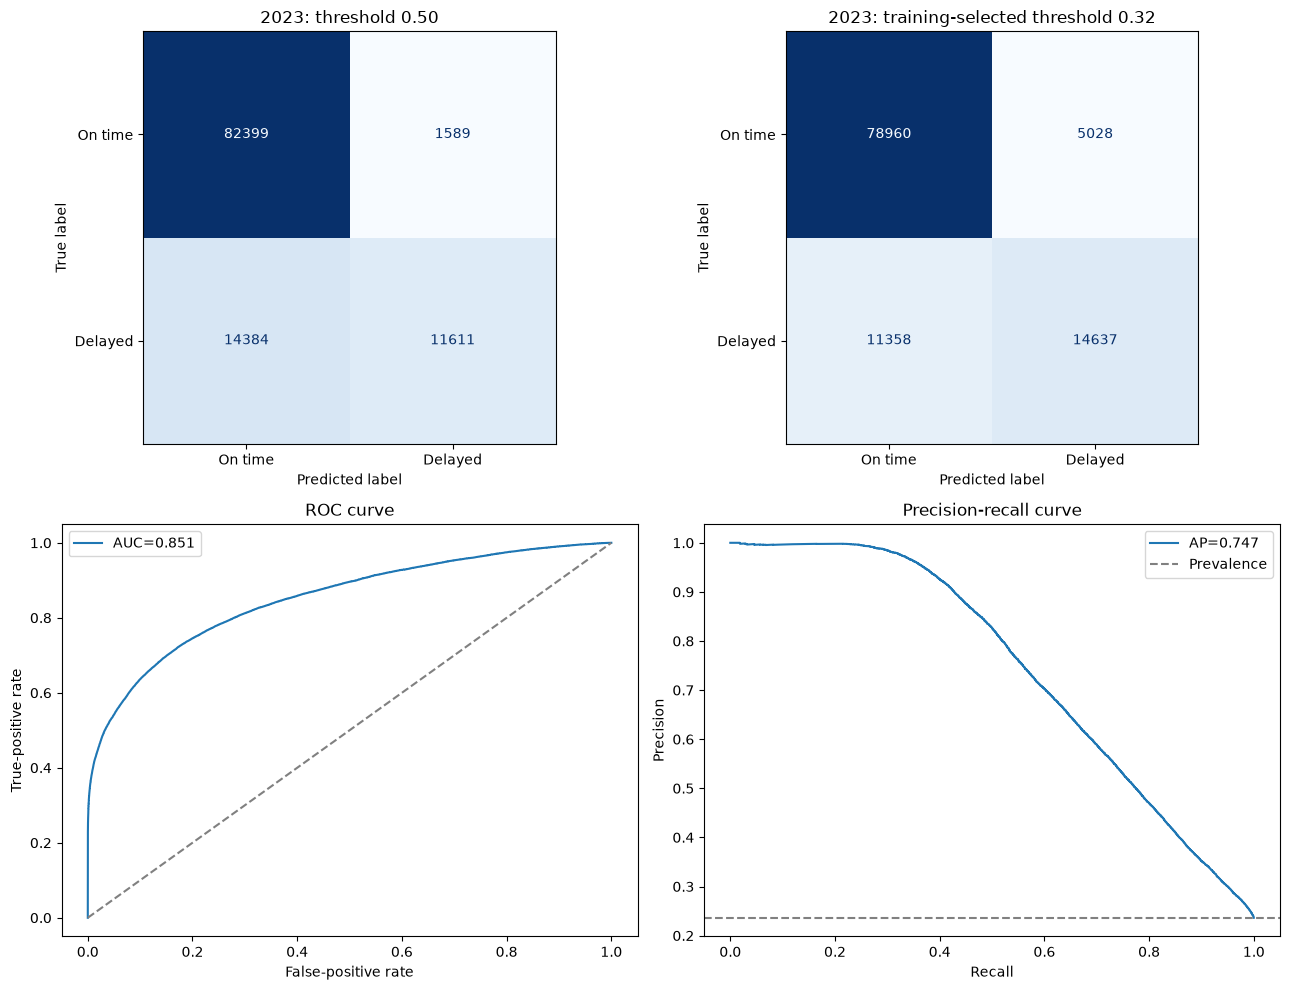

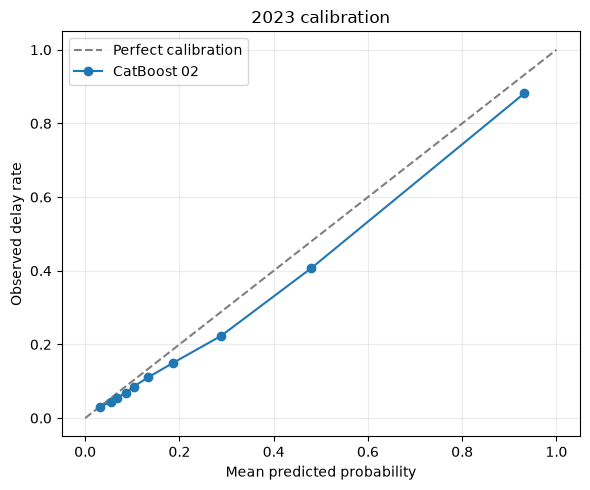

In [12]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(y_validation, validation_probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(y_validation, validation_probabilities)
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ConfusionMatrixDisplay.from_predictions(y_validation, default_predictions,
    display_labels=["On time", "Delayed"], cmap="Blues", colorbar=False, ax=axes[0, 0])
axes[0, 0].set_title("2023: threshold 0.50")
ConfusionMatrixDisplay.from_predictions(y_validation, selected_predictions,
    display_labels=["On time", "Delayed"], cmap="Blues", colorbar=False, ax=axes[0, 1])
axes[0, 1].set_title(f"2023: training-selected threshold {selected_threshold:.2f}")
axes[1, 0].plot(false_positive_rate, true_positive_rate, label=f"AUC={roc_auc_score(y_validation, validation_probabilities):.3f}")
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set(xlabel="False-positive rate", ylabel="True-positive rate", title="ROC curve"); axes[1, 0].legend()
axes[1, 1].plot(curve_recall, curve_precision, label=f"AP={average_precision_score(y_validation, validation_probabilities):.3f}")
axes[1, 1].axhline(y_validation.mean(), linestyle="--", color="gray", label="Prevalence")
axes[1, 1].set(xlabel="Recall", ylabel="Precision", title="Precision-recall curve"); axes[1, 1].legend()
fig.tight_layout(); plt.show()
predicted, observed = calibration_curve(y_validation, validation_probabilities, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(predicted, observed, marker="o", label="CatBoost 02")
ax.set(xlabel="Mean predicted probability", ylabel="Observed delay rate", title="2023 calibration")
ax.legend(); ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

## Inspect feature importance and publishable values

CatBoost importance describes predictive contribution within this fitted model, not causation. The final-tail assignment caveat applies regardless of importance ranking.

In [13]:
feature_importance = (pd.DataFrame({
    "feature": feature_columns, "importance": best_catboost_model.get_feature_importance(),
}).sort_values("importance", ascending=False).reset_index(drop=True))
display(feature_importance.head(25))
display(feature_importance[feature_importance["feature"].str.contains("ROTATION_|BACKLOG_", regex=True)])

default = evaluation_results.loc["CatBoost 02 (default)"]
selected = evaluation_results.loc["CatBoost 02 (training-selected)"]
publishable_summary = pd.Series({
    "CatBoost version": catboost.__version__,
    "source fields": len(feature_columns),
    "selected depth": selected_parameters["depth"],
    "selected learning rate": selected_parameters["learning_rate"],
    "selected L2 leaf regularization": selected_parameters["l2_leaf_reg"],
    "selected class weighting": selected_parameters["class_weighting"],
    "selected trees": selected_iterations,
    "training CV AP": best_candidate["mean_average_precision"],
    "validation prevalence": y_validation.mean(),
    "validation AP": default["average_precision"],
    "validation ROC AUC": default["roc_auc"],
    "validation Brier": default["brier_score"],
    "selected threshold": selected_threshold,
    "selected-threshold accuracy": selected["accuracy"],
    "selected-threshold balanced accuracy": selected["balanced_accuracy"],
    "selected-threshold precision": selected["precision"],
    "selected-threshold recall": selected["recall"],
    "selected-threshold F1": selected["f1"],
    "selected-threshold MCC": selected["mcc"],
    "validation AP excluding NOT_ARRIVED": diagnostic_results.loc["excluding NOT_ARRIVED", "average_precision"],
    "search seconds": search_seconds, "final fit seconds": final_fit_seconds,
}, name="CatBoost 1A Experiment 02 Appendix D values")
publishable_summary.to_frame()

,feature,importance
0,ROTATION_ACTUAL_TURN_MINUTES,14.2494
1,ROTATION_LOG_ACTUAL_TURN_MINUTES,11.9599
2,ROTATION_STATUS,10.5901
3,ROTATION_INBOUND_ARR_DELAY,6.8154
4,ROTATION_LOG_SCHEDULED_TURN_MINUTES,6.0639
5,BACKLOG_W60_PENDING_COUNT,4.5609
6,Reporting_Airline,4.0973
7,CRSDepTime,3.9576
8,ROTATION_SCHEDULED_TURN_MINUTES,3.7365
9,Distance,3.0706


,feature,importance
0,ROTATION_ACTUAL_TURN_MINUTES,14.2494
1,ROTATION_LOG_ACTUAL_TURN_MINUTES,11.9599
2,ROTATION_STATUS,10.5901
3,ROTATION_INBOUND_ARR_DELAY,6.8154
4,ROTATION_LOG_SCHEDULED_TURN_MINUTES,6.0639
5,BACKLOG_W60_PENDING_COUNT,4.5609
8,ROTATION_SCHEDULED_TURN_MINUTES,3.7365
10,ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF,2.9627
11,BACKLOG_W60_MEAN_DEP_DELAY,2.8435
13,ROTATION_INBOUND_DELAYED_15,2.4474


,CatBoost 1A Experiment 02 Appendix D values
CatBoost version,1.2.10
source fields,36
selected depth,6
selected learning rate,0.0300
selected L2 leaf regularization,3.0000
selected class weighting,None
selected trees,683
training CV AP,0.7025
validation prevalence,0.2364
validation AP,0.7473


## Interpretation checklist

1. Does CatBoost improve 2019 temporal AP and 2023 AP, ROC AUC, or Brier score over Logistic Regression 08?
2. Does any gain persist after excluding `NOT_ARRIVED` and where rotation is unavailable or excluded?
3. Does native nonlinear modeling improve threshold F1 and MCC without materially weakening calibration?
4. Are rotation and W60 backlog fields prominent in the fitted importance ranking?
5. Is the improvement large enough to justify additional model complexity for the final Model 1A candidate?
6. Preserve the final-tail caveat: this remains a retrospective upper bound until timestamped assignment data are available.